In [ ]:
class Splitwise:
    def __init__(self, members):
        self.members = members
        self.expenses = []
        self.balances = {member: 0 for member in members}

    def add_expense(self):
        try:
            payer = input("Enter the name of the payer: ")
            if payer not in self.members:
                print("Payer is not a member of the group.")
                return

            amount = float(input("Enter the amount of the bill: "))
            participants = input("Enter the names of participants (comma-separated): ").split(',')

            participants = [participant.strip() for participant in participants]
            for participant in participants:
                if participant not in self.members:
                    print(f"{participant} is not a member of the group.")
                    return

            share = amount / len(participants)

            self.balances[payer] += amount - share

            for person in participants:
                if person != payer:
                    self.balances[person] -= share

            self.expenses.append({'amount': amount, 'payer': payer, 'participants': participants})
            print("Expense added successfully!")
        except ValueError:
            print("Invalid input. Please enter a valid amount.")

    def show_balances(self):
        print("\nCurrent Balances:")
        for person, balance in self.balances.items():
            if balance > 0:
                print(f"{person} should receive {balance:.2f}")
            elif balance < 0:
                print(f"{person} owes {-balance:.2f}")
            else:
                print(f"{person} is settled up")

    def simplify_debts(self):
        settled_balances = {k: v for k, v in self.balances.items() if v != 0}

        creditors = [(k, v) for k, v in settled_balances.items() if v > 0]
        debtors = [(k, -v) for k, v in settled_balances.items() if v < 0]

        print("\nSimplified Debts:")
        while creditors and debtors:
            creditor, credit_amount = creditors.pop(0)
            debtor, debt_amount = debtors.pop(0)
            settlement = min(credit_amount, debt_amount)
            print(f"{debtor} pays {settlement:.2f} to {creditor}")

            credit_amount -= settlement
            debt_amount -= settlement

            if credit_amount > 0:
                creditors.insert(0, (creditor, credit_amount))
            if debt_amount > 0:
                debtors.insert(0, (debtor, debt_amount))

def main():
    print("Welcome to the Splitwise Application!")
    n = int(input("Enter the number of members in the group: "))
    members = []

    for i in range(n):
        member = input(f"Enter the name of member {i + 1}: ")
        members.append(member.strip())

    app = Splitwise(members)

    while True:
        print("\nMenu:")
        print("1. Add Expense")
        print("2. Show Balances")
        print("3. Simplify Debts")
        print("4. Exit")

        choice = input("Enter your choice (1-4): ")

        if choice == '1':
            app.add_expense()
        elif choice == '2':
            app.show_balances()
        elif choice == '3':
            app.simplify_debts()
        elif choice == '4':
            print("Exiting the application. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 4.")

if __name__ == "__main__":
    main()


Welcome to the Splitwise Application!
Enter the number of members in the group: 3
Enter the name of member 1: a
Enter the name of member 2: b
Enter the name of member 3: c

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Exit
Enter your choice (1-4): 1
Enter the name of the payer: a
Enter the amount of the bill: 200
Enter the names of participants (comma-separated): b,c
Expense added successfully!
b should give 100.00 to a
c should give 100.00 to a

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Exit
Enter your choice (1-4): 1
Enter the name of the payer: a
Enter the amount of the bill: 300
Enter the names of participants (comma-separated): a,b,c
a should receive 200.00
Expense added successfully!
b should give 100.00 to a
c should give 100.00 to a

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Exit
Enter your choice (1-4): 2

Current Balances:
a should receive 400.00
b owes 200.00
c owes 200.00

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debt

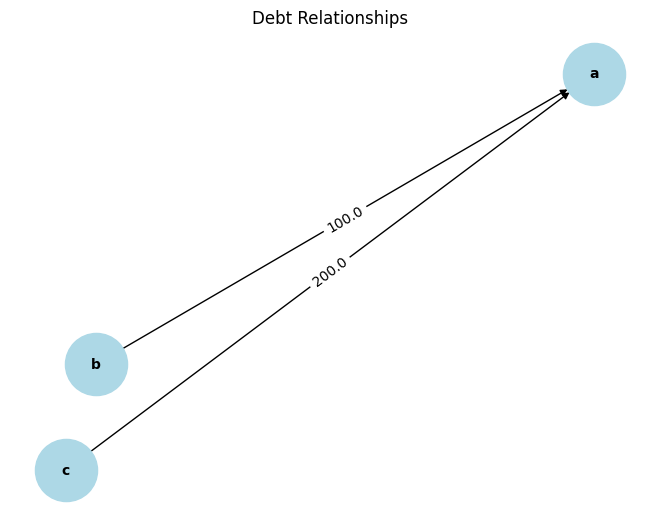


Simplified Debts:
b pays 100.00 to a
c pays 200.00 to a

Graph After Simplification:


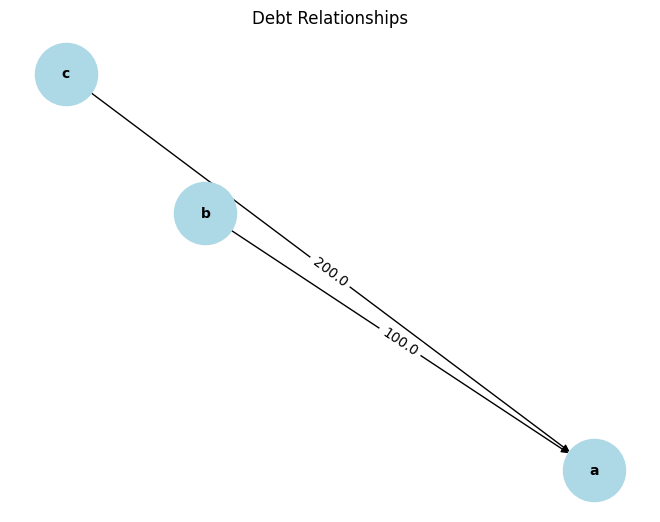


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Exit
Enter your choice (1-4): 2

Current Balances:
a should receive 300.00
b owes 100.00
c owes 200.00

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Exit
Enter your choice (1-4): 4
Exiting the application. Goodbye!


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

class Splitwise:
    def __init__(self, members):
        self.members = members
        self.expenses = []
        self.balances = {member: 0 for member in members}

    def add_expense(self):
        try:
            payer = input("Enter the name of the payer: ")
            if payer not in self.members:
                print("Payer is not a member of the group.")
                return

            amount = float(input("Enter the amount of the bill: "))
            participants = input("Enter the names of participants (comma-separated): ").split(',')

            participants = [participant.strip() for participant in participants]
            for participant in participants:
                if participant not in self.members:
                    print(f"{participant} is not a member of the group.")
                    return

            if payer in participants:
                share = amount / len(participants)
                participants.remove(payer)
                self.balances[payer] += amount - share
                print(f"{payer} should receive {amount - share:.2f}")
            else:
                share = amount / len(participants)
                self.balances[payer] += amount

            for person in participants:
                self.balances[person] -= share

            self.expenses.append({'amount': amount, 'payer': payer, 'participants': participants})
            print("Expense added successfully!")

            for person in participants:
                print(f"{person} should give {share:.2f} to {payer}")

        except ValueError:
            print("Invalid input. Please enter a valid amount.")

    def show_balances(self):
        print("\nCurrent Balances:")
        for person, balance in self.balances.items():
            if balance > 0:
                print(f"{person} should receive {balance:.2f}")
            elif balance < 0:
                print(f"{person} owes {-balance:.2f}")
            else:
                print(f"{person} is settled up")

    def draw_graph(self, debts):
        G = nx.DiGraph()

        for debtor, creditor, amount in debts:
            G.add_edge(debtor, creditor, weight=amount)

        pos = nx.spring_layout(G)

        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrows=True)

        edge_labels = {(debtor, creditor): amount for debtor, creditor, amount in debts}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

        plt.title("Debt Relationships")
        plt.show()

    def simplify_debts(self):
        settled_balances = {k: v for k, v in self.balances.items() if v != 0}

        creditors = [(k, v) for k, v in settled_balances.items() if v > 0]
        debtors = [(k, -v) for k, v in settled_balances.items() if v < 0]

        debts_before = []
        for creditor, credit_amount in creditors:
            for debtor, debt_amount in debtors:
                debts_before.append((debtor, creditor, min(credit_amount, debt_amount)))

        print("\nGraph Before Simplification:")
        self.draw_graph(debts_before)

        print("\nSimplified Debts:")
        simplified_debts = []
        while creditors and debtors:
            creditor, credit_amount = creditors.pop(0)
            debtor, debt_amount = debtors.pop(0)
            settlement = min(credit_amount, debt_amount)
            print(f"{debtor} pays {settlement:.2f} to {creditor}")
            simplified_debts.append((debtor, creditor, settlement))

            credit_amount -= settlement
            debt_amount -= settlement

            if credit_amount > 0:
                creditors.insert(0, (creditor, credit_amount))
            if debt_amount > 0:
                debtors.insert(0, (debtor, debt_amount))

        print("\nGraph After Simplification:")
        self.draw_graph(simplified_debts)

def main():
    print("Welcome to the Splitwise Application!")
    n = int(input("Enter the number of members in the group: "))
    members = []

    for i in range(n):
        member = input(f"Enter the name of member {i + 1}: ")
        members.append(member.strip())

    app = Splitwise(members)

    while True:
        print("\nMenu:")
        print("1. Add Expense")
        print("2. Show Balances")
        print("3. Simplify Debts")
        print("4. Exit")

        choice = input("Enter your choice (1-4): ")

        if choice == '1':
            app.add_expense()
        elif choice == '2':
            app.show_balances()
        elif choice == '3':
            app.simplify_debts()
        elif choice == '4':
            print("Exiting the application. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 4.")

if __name__ == "__main__":
    main()


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

class Splitwise:
    def __init__(self, members):
        self.members = members
        self.expenses = []
        self.balances = {member: 0 for member in members}

    def add_expense(self):
        try:
            payer = input("Enter the name of the payer: ")
            if payer not in self.members:
                print("Payer is not a member of the group.")
                return

            amount = float(input("Enter the amount of the bill: "))
            participants = input("Enter the names of participants (comma-separated): ").split(',')

            participants = [participant.strip() for participant in participants]
            for participant in participants:
                if participant not in self.members:
                    print(f"{participant} is not a member of the group.")
                    return

            share = amount / len(participants)

            for person in participants:
                if person == payer:
                    self.balances[payer] += (amount - share)
                else:
                    self.balances[person] -= share

            self.expenses.append({'amount': amount, 'payer': payer, 'participants': participants})
            print("Expense added successfully!")
        except ValueError:
            print("Invalid input. Please enter a valid amount.")

    def show_balances(self):
        print("\nCurrent Balances:")
        for person, balance in self.balances.items():
            if balance > 0:
                print(f"{person} should receive {balance:.2f}")
            elif balance < 0:
                print(f"{person} owes {-balance:.2f}")
            else:
                print(f"{person} is settled up")

    def draw_graph(self, edges, title):
        graph = nx.DiGraph()
        graph.add_edges_from(edges)
        pos = nx.spring_layout(graph)
        plt.figure(figsize=(8, 6))
        nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, font_weight='bold', edge_color='gray')
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in graph.edges(data=True)}
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
        plt.title(title)
        plt.show()

    def simplify_debts(self):
        settled_balances = {k: v for k, v in self.balances.items() if v != 0}

        creditors = [(k, v) for k, v in settled_balances.items() if v > 0]
        debtors = [(k, -v) for k, v in settled_balances.items() if v < 0]

        edges_before = []
        for debtor, debt_amount in debtors:
            for creditor, credit_amount in creditors:
                if debt_amount <= credit_amount:
                    edges_before.append((debtor, creditor, {'weight': debt_amount}))
                else:
                    edges_before.append((debtor, creditor, {'weight': credit_amount}))

        print("\nGraph Before Simplification:")
        self.draw_graph(edges_before, "Graph Before Simplification")

        print("\nSimplified Debts:")
        edges_after = []
        while creditors and debtors:
            creditor, credit_amount = creditors.pop(0)
            debtor, debt_amount = debtors.pop(0)
            settlement = min(credit_amount, debt_amount)
            print(f"{debtor} pays {settlement:.2f} to {creditor}")
            edges_after.append((debtor, creditor, {'weight': settlement}))

            # Update balances after settlement
            credit_amount -= settlement
            debt_amount -= settlement

            if credit_amount > 0:
                creditors.insert(0, (creditor, credit_amount))
            if debt_amount > 0:
                debtors.insert(0, (debtor, debt_amount))

        print("\nGraph After Simplification:")
        self.draw_graph(edges_after, "Graph After Simplification")

    def settle_up(self):
        debtor = input("Enter the name of the debtor: ")
        creditor = input("Enter the name of the creditor: ")
        amount = float(input("Enter the amount to settle up: "))

        if debtor not in self.members or creditor not in self.members:
            print("Invalid member(s). Please enter valid group members.")
            return

        if self.balances[debtor] + amount > 0 or self.balances[creditor] - amount < 0:
            print("Settlement amount exceeds the balance. Please enter a valid amount.")
            return

        self.balances[debtor] += amount
        self.balances[creditor] -= amount
        print(f"{debtor} settled {amount:.2f} with {creditor}.")

def main():
    print("Welcome to the Splitwise Application!")
    n = int(input("Enter the number of members in the group: "))
    members = [input(f"Enter the name of member {i + 1}: ").strip() for i in range(n)]

    app = Splitwise(members)

    while True:
        print("\nMenu:")
        print("1. Add Expense")
        print("2. Show Balances")
        print("3. Simplify Debts")
        print("4. Settle Up")
        print("5. Exit")

        choice = input("Enter your choice (1-5): ")

        if choice == '1':
            app.add_expense()
        elif choice == '2':
            app.show_balances()
        elif choice == '3':
            app.simplify_debts()
        elif choice == '4':
            app.settle_up()
        elif choice == '5':
            print("Exiting the application. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 5.")

if __name__ == "__main__":
    main()


Welcome to the Splitwise Application!

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
Expense added successfully!

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit

Current Balances:
a should receive 759.00
b is settled up
c owes 253.00
d owes 253.00
e owes 253.00
f is settled up
g is settled up

Expenses so far:
{'amount': 759.0, 'payer': 'a', 'participants': ['c', 'd', 'e']} 


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
Creditors: [('a', 759.0)]
Debtors: [('c', 253.0), ('d', 253.0), ('e', 253.0)]

Simplified Debts:
c pays 253.00 to a
d pays 253.00 to a
e pays 253.00 to a

Graph After Simplification:


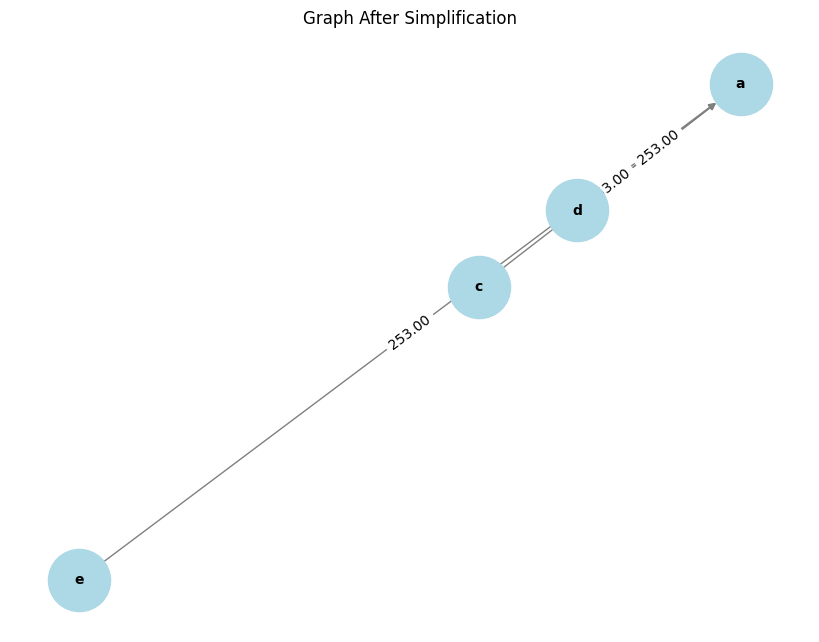


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
Expense added successfully!

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit

Current Balances:
a should receive 509.00
b owes 250.00
c should receive 497.00
d owes 253.00
e owes 503.00
f is settled up
g is settled up

Expenses so far:
{'amount': 759.0, 'payer': 'a', 'participants': ['c', 'd', 'e']} 

{'amount': 1000.0, 'payer': 'c', 'participants': ['a', 'b', 'e', 'c']} 


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit

Current Balances:
a should receive 509.00
b owes 250.00
c should receive 497.00
d owes 253.00
e owes 503.00
f is settled up
g is settled up

Expenses so far:
{'amount': 759.0, 'payer': 'a', 'participants': ['c', 'd', 'e']} 

{'amount': 1000.0, 'payer': 'c', 'participants': ['a', 'b', 'e', 'c']} 


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
Creditors: [('a', 509.0), ('c', 497.0)]
Debtors: [('b', 250.0)

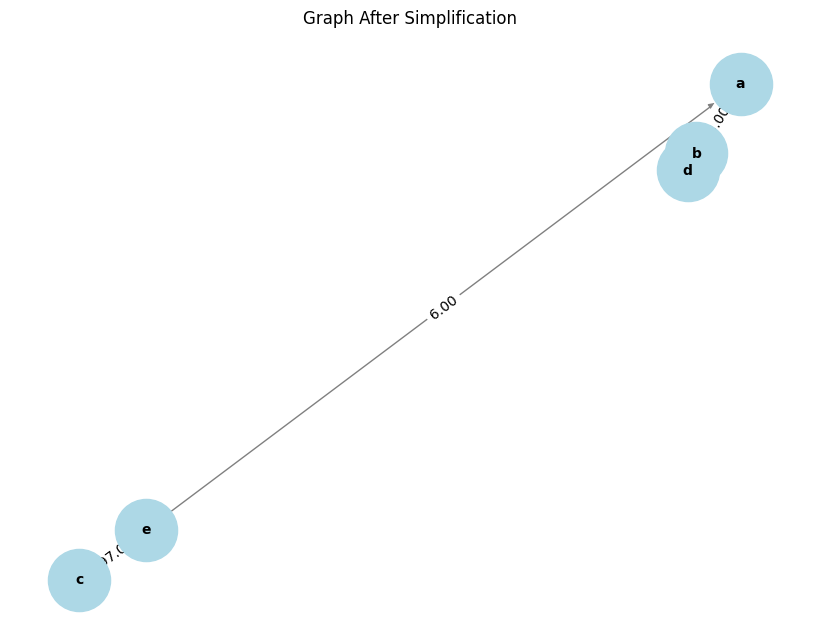


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
b settled 0.00 with c.

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit
b settled 240.00 with a.

Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit

Current Balances:
a should receive 269.00
b owes 10.00
c should receive 497.00
d owes 253.00
e owes 503.00
f is settled up
g is settled up

Expenses so far:
{'amount': 759.0, 'payer': 'a', 'participants': ['c', 'd', 'e']} 

{'amount': 1000.0, 'payer': 'c', 'participants': ['a', 'b', 'e', 'c']} 


Menu:
1. Add Expense
2. Show Balances
3. Simplify Debts
4. Settle Up
5. Exit


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

class Splitwise:
    def __init__(self, members):
        self.members = members
        self.expenses = []
        self.balances = {member: 0 for member in members}

    def show_balances(self):
        print("\nCurrent Balances:")
        for person, balance in self.balances.items():
            if balance > 0:
                print(f"{person} should receive {balance:.2f}")
            elif balance < 0:
                print(f"{person} owes {-balance:.2f}")
            else:
                print(f"{person} is settled up")
        print("\nExpenses so far:")
        for expense in self.expenses:
          print(expense,"\n")

    def draw_graph(self, edges, title):
        graph = nx.DiGraph()
        graph.add_edges_from(edges)
        pos = nx.spring_layout(graph)
        plt.figure(figsize=(8, 6))
        nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, font_weight='bold', edge_color='gray')
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in graph.edges(data=True)}
        nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
        plt.title(title)
        plt.show()
    def add_expense(self):
        try:
            payer = input("Enter the name of the payer: ")
            if payer not in self.members:
                print("Payer is not a member of the group.")
                return

            amount = float(input("Enter the amount of the bill: "))
            participants = input("Enter the names of participants (comma-separated): ").split(',')

            participants = [participant.strip() for participant in participants]
            for participant in participants:
                if participant not in self.members:
                    print(f"{participant} is not a member of the group.")
                    return

            share = amount / len(participants)

            if payer not in participants:
              self.balances[payer]+=amount
            for person in participants:
                if person == payer:
                    self.balances[payer] += amount-share
                else:
                    self.balances[person] -= share

            # Store the expense
            self.expenses.append({'amount': amount, 'payer': payer, 'participants': participants})
            print("Expense added successfully!")

        except ValueError:
            print("Invalid input. Please enter a valid amount.")
    def simplify_debts(self):
        settled_balances = {k: v for k, v in self.balances.items() if v != 0}

        creditors = [(k, v) for k, v in settled_balances.items() if v > 0]
        debtors = [(k, -v) for k, v in settled_balances.items() if v < 0]

        print(f"Creditors: {creditors}")
        print(f"Debtors: {debtors}")

        if not creditors:
            print("No creditors available to simplify debts.")
            return

        print("\nSimplified Debts:")
        edges_after = []
        while creditors and debtors:
            creditor, credit_amount = creditors.pop(0)
            debtor, debt_amount = debtors.pop(0)
            settlement = min(credit_amount, debt_amount)
            print(f"{debtor} pays {settlement:.2f} to {creditor}")
            edges_after.append((debtor, creditor, {'weight': settlement}))

            credit_amount -= settlement
            debt_amount -= settlement

            if credit_amount > 0:
                creditors.insert(0, (creditor, credit_amount))
            if debt_amount > 0:
                debtors.insert(0, (debtor, debt_amount))

        print("\nGraph After Simplification:")
        self.draw_graph(edges_after, "Graph After Simplification")
    def settle_up(self):
        debtor = input("Enter the name of the debtor: ")
        creditor = input("Enter the name of the creditor: ")

        try:
            amount = float(input("Enter the amount to settle up: "))

            if debtor not in self.members or creditor not in self.members:
                print("Invalid member(s). Please enter valid group members.")
                return

            if self.balances[debtor] + amount > 0 or self.balances[creditor] - amount < 0:
                print("Settlement amount exceeds the balance. Please enter a valid amount.")
                return

            self.balances[debtor] += amount
            self.balances[creditor] -= amount
            print(f"{debtor} settled {amount:.2f} with {creditor}.")

        except ValueError:
            print("Invalid input. Please enter a valid amount.")

def main():
    print("Welcome to the Splitwise Application!")
    n = int(input("Enter the number of members in the group: "))
    members = [input(f"Enter the name of member {i + 1}: ").strip() for i in range(n)]

    app = Splitwise(members)

    while True:
        print("\nMenu:")
        print("1. Add Expense")
        print("2. Show Balances")
        print("3. Simplify Debts")
        print("4. Settle Up")
        print("5. Exit")

        choice = input("Enter your choice (1-5): ")

        if choice == '1':
            app.add_expense()
        elif choice == '2':
            app.show_balances()
        elif choice == '3':
            app.simplify_debts()
        elif choice == '4':
            app.settle_up()
        elif choice == '5':
            print("Exiting the application. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter a number between 1 and 5.")

if __name__ == "__main__":
    main()